  5000 | lr 4.53e-04 | data 6.83e-02 | phys 9.21e+07 | ic 1.11e+02 | L 1.118e-01 R 2.036e-01 C 3.484e-02 F -1.955e+00
 10000 | lr 3.29e-04 | data 3.72e-02 | phys 1.16e+07 | ic 1.91e+02 | L 4.286e-02 R 7.965e-02 C 3.458e-03 F -2.337e+00
 15000 | lr 1.76e-04 | data 1.20e-02 | phys 3.18e+06 | ic 6.65e+00 | L 2.218e-02 R 4.013e-02 C 3.817e-03 F -1.464e+00
 20000 | lr 5.23e-05 | data 1.18e-02 | phys 1.48e+06 | ic 2.71e+00 | L 1.483e-02 R 2.697e-02 C 5.739e-03 F -1.384e+00
 25000 | lr 5.00e-06 | data 1.81e-03 | phys 1.40e+06 | ic 7.80e-02 | L 1.346e-02 R 2.456e-02 C 6.306e-03 F -1.480e+00


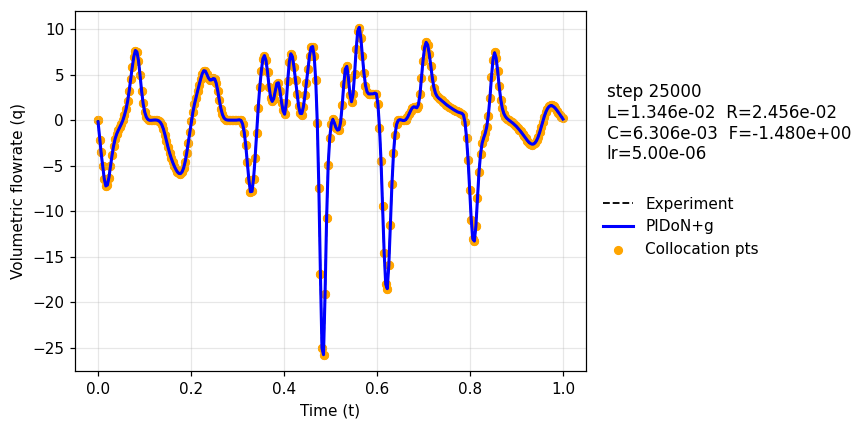

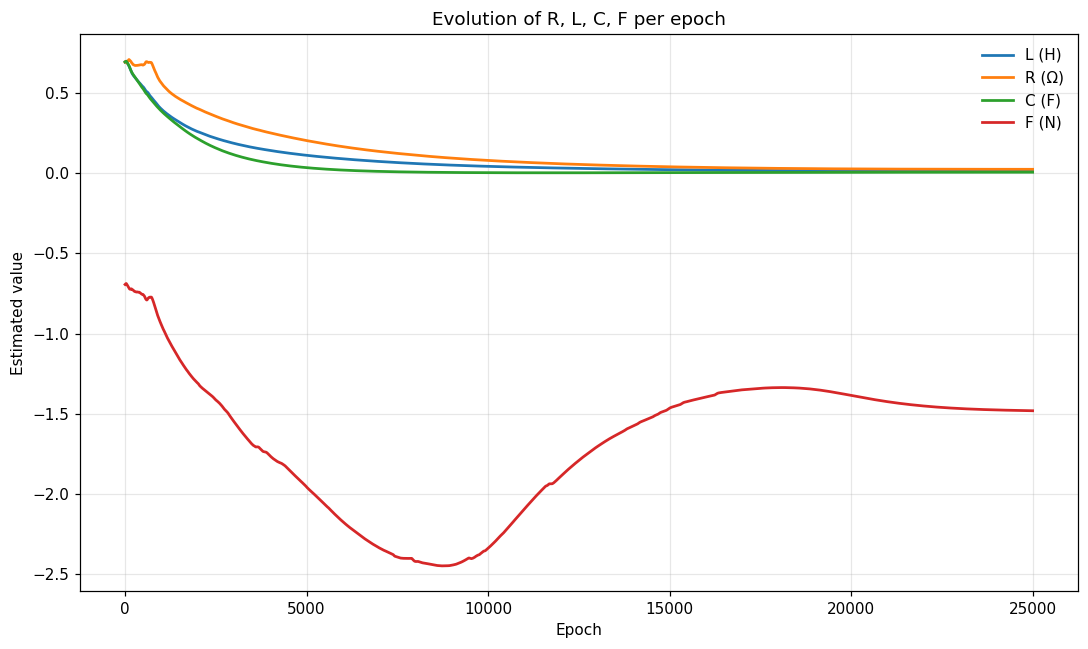

Saved files for Excel reproduction:
 - D:\lsy_DL\Parameter identification\EG 50\PIDoN_logs\flowrate-time.csv    (Time, Experiment, PIDoN+g, Collocation pts)
 - D:\lsy_DL\Parameter identification\EG 50\PIDoN_logs\parameter-epoch.csv    (epoch, R, L, C, F)
Additional logs:
 - D:\lsy_DL\Parameter identification\EG 50\PIDoN_logs\RLCF_per_epoch_20250909_045601.csv
 - D:\lsy_DL\Parameter identification\EG 50\PIDoN_logs\RLCF_final_20250909_045601.csv


In [57]:
# ═════════════ 0. 라이브러리 · 환경 ─══════════════════════════
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

# ═════════════ 1. 외력항 f_ext(t,F) ─═════════════════════════
α_scale = 1e-2
Vmax    = 40* α_scale
t1, t2, t3 = 6e-3, 26e-3, 32e-3
σ = 0.0565
H = lambda τ: 0.5 * (1.0 + torch.tanh(σ * τ))
def f_ext(t, F_gain):
    return (F_gain * Vmax / t1)*(H(t)-H(t-t1)) + \
           (F_gain * Vmax / (t3-t2))*(H(t-t2)-H(t-t3))

# ═════════════ 2. 실험 CSV → 학습·검증 세트 ─══════════════════
def load_experiment_csv(csv_path, t_end=1.0, n_full=300,
                        data_range=(0.0, 1.0), n_data=600):
    df     = pd.read_csv(csv_path)
    vals   = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full,
                            device=DEVICE).view(-1, 1)

    s, e = (int(data_range[0]/t_end*(n_full-1)),
            int(data_range[1]/t_end*(n_full-1)))
    idx  = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

csv_path = r"D:\lsy_DL\Parameter identification\EG 50\3. EG50_40V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)

# ═════════════ 3. PIDoN + g-Net (g5 hidden 추가) ─════════════
class PIDoN(nn.Module):
    """
    Width = 256  (all hidden layers)
      • Branch : 4  → 256×5 → latent
      • Trunk  : 1  → 256×5 → latent
      • g-Net  : 1  → 256×5 → latent  (g1–g5)
    """
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4,   256)), ("a1", nn.GELU() ),
            ("b2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("a3", nn.GELU() ),
            ("b4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("a5", nn.GELU()),   # 추가된 hidden
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)            # [B, latent]
        T = self.trunk(t)                  # [B, latent]
        G = torch.sigmoid(self.g_net(t))   # [B, latent]
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias

model = PIDoN(latent=32).to(DEVICE)

# ═════════════ 4. 추정 파라미터 (부호 제약) ─══════════════════
L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))

pos = lambda p: F.softplus(p) + 1e-4     # > 0
neg = lambda p: -(F.softplus(p) + 1e-4)  # < 0

# ═════════════ 5. 손실 가중치 & 학습 설정 ─═══════════════════
DATA_WEIGHT = 1e6
PHYS_WEIGHT = 1e-4
IC_WEIGHT   = 1e1

t_phys = torch.linspace(0, 1, 100, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic   = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

LR_INIT = 5e-4
optim   = torch.optim.Adam(list(model.parameters()) +
                           [L_raw, R_raw, C_raw, F_raw], lr=LR_INIT)

# ── 스케줄러: CosineAnnealingLR (에폭 전체에 걸쳐 lr ↓, 최솟값 eta_min)
EPOCHS       = 25_000
PLOT_EVERY   = 25_000
PRINT_EVERY  = 5_000
scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optim, T_max=EPOCHS, eta_min=LR_INIT*1e-2
              )

# ═════════════ 6. 파라미터·LR 기록 버퍼 ─═════════════════════
param_hist = {"epoch": [], "L": [], "R": [], "C": [], "F": []}
lr_hist    = {"epoch": [], "lr": []}

# ═════════════ 7. 학습 루프 ─═════════════════════════════════
for step in range(1, EPOCHS + 1):
    optim.zero_grad()

    # 파라미터 재구성
    L_hat, R_hat, C_hat = map(pos, (L_raw, R_raw, C_raw))
    F_hat               = neg(F_raw)
    p_vec = torch.tensor([[L_hat.item(), R_hat.item(),
                           C_hat.item(), F_hat.item()]], device=DEVICE)

    # (a) 데이터 손실
    y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
    loss_data   = F.mse_loss(y_pred_data, y_data)

    # (b) 물리 잔차
    y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
    dy  = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys),
                              create_graph=True, retain_graph=True)[0]
    d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy),
                              create_graph=True, retain_graph=True)[0]
    res       = L_hat*d2y + R_hat*dy + (1.0/C_hat)*y_phys - f_ext(t_phys, F_hat)
    loss_phys = res.pow(2).mean()

    # (c) 초기조건 손실
    y0  = model(t_ic, p_vec)
    dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0),
                              create_graph=True, retain_graph=True)[0]
    loss_ic = y0.pow(2) + dy0.pow(2)

    # (d) 총 손실
    total_loss = (DATA_WEIGHT * loss_data +
                  PHYS_WEIGHT * loss_phys +
                  IC_WEIGHT   * loss_ic)
    total_loss.backward()
    optim.step()

    # 스케줄러 스텝(optimizer.step() 직후 호출 권장)
    scheduler.step()

    # (e) 파라미터·LR 기록
    param_hist["epoch"].append(step)
    param_hist["L"].append(L_hat.item())
    param_hist["R"].append(R_hat.item())
    param_hist["C"].append(C_hat.item())
    param_hist["F"].append(F_hat.item())

    lr_hist["epoch"].append(step)
    lr_hist["lr"].append(float(optim.param_groups[0]["lr"]))

    # ── 로그 출력
    if step % PRINT_EVERY == 0:
        cur_lr = optim.param_groups[0]["lr"]
        print(f"{step:>6} | lr {cur_lr:.2e} | data {loss_data.item():.2e} | "
              f"phys {loss_phys.item():.2e} | ic {loss_ic.item():.2e} | "
              f"L {L_hat.item():.3e} R {R_hat.item():.3e} "
              f"C {C_hat.item():.3e} F {F_hat.item():.3e}")

    # ── 중간 결과 플롯
    if step % PLOT_EVERY == 0:
        with torch.no_grad():
            y_hat_mid = model(t_full, p_vec.repeat(t_full.size(0), 1)).cpu()

        plt.figure(figsize=(8, 4))
        plt.plot(t_full.cpu(), y_full.cpu(), 'k--', lw=1.2, label='Experiment')
        plt.plot(t_full.cpu(), y_hat_mid, 'b', lw=2.0, label='PIDoN+g')
        plt.scatter(x_data.cpu(), y_data.cpu(), c='orange', s=25,
                    label='Collocation pts')
        plt.xlabel("Time (t)")
        plt.ylabel("Volumetric flowrate (q)")
        plt.grid(alpha=0.3)
        plt.legend(frameon=False, loc=(1.02, 0.30))
        plt.text(1.04, 0.80,
                 f"step {step}\n"
                 f"L={L_hat.item():.3e}  R={R_hat.item():.3e}\n"
                 f"C={C_hat.item():.3e}  F={F_hat.item():.3e}\n"
                 f"lr={optim.param_groups[0]['lr']:.2e}",
                 transform=plt.gca().transAxes, va='top', fontsize=11)
        plt.tight_layout()
        plt.show()

# ═════════════ 8. [R, L, C, F] / epoch 시각화 ─═══════════════
plt.figure(figsize=(10, 6))
plt.plot(param_hist["epoch"], param_hist["L"], label="L (H)", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["R"], label="R (Ω)", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["C"], label="C (F)", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["F"], label="F (N)", lw=1.8)
plt.xlabel("Epoch")
plt.ylabel("Estimated value")
plt.title("Evolution of R, L, C, F per epoch")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ═════════════ 9. CSV 내보내기 ─ 엑셀 재현용(요청사항) ─══════════
# 실험 CSV와 동일한 폴더 하위에 PIDoN_logs 폴더를 만들고 저장
save_root = os.path.join(os.path.dirname(csv_path), "PIDoN_logs")
os.makedirs(save_root, exist_ok=True)

# 실행 시각 기반 식별자(기존 로그 유지용)
run_id = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

# (A) per-epoch 파라미터 로그: 요청 파일명 "parameter-epoch.csv"
df_params = pd.DataFrame({
    "epoch": param_hist["epoch"],
    "R":     param_hist["R"],
    "L":     param_hist["L"],
    "C":     param_hist["C"],
    "F":     param_hist["F"],
})
param_epoch_csv = os.path.join(save_root, "parameter-epoch.csv")
df_params.to_csv(param_epoch_csv, index=False, float_format="%.10e")

# (B) 추가: 기존 per-run 백업 로그(유지)
params_csv_path = os.path.join(save_root, f"RLCF_per_epoch_{run_id}.csv")
df_params.to_csv(params_csv_path, index=False, float_format="%.10e")
final_row = df_params.iloc[-1:]
final_csv_path = os.path.join(save_root, f"RLCF_final_{run_id}.csv")
final_row.to_csv(final_csv_path, index=False, float_format="%.10e")

# (C) flowrate-time.csv: Time, Experiment, PIDoN+g, Collocation pts
with torch.no_grad():
    # 최종 파라미터로 y_hat 재계산
    L_fin, R_fin, C_fin = map(pos, (L_raw, R_raw, C_raw))
    F_fin               = neg(F_raw)
    p_vec_fin = torch.tensor([[L_fin.item(), R_fin.item(),
                               C_fin.item(), F_fin.item()]], device=DEVICE)
    y_hat = model(t_full, p_vec_fin.repeat(t_full.size(0), 1))

# Collocation 값을 전체 시간축에 매핑(해당 시각 외에는 빈칸)
t_end_val    = float(t_full[-1].item())
n_full_val   = int(t_full.shape[0])
idx_est = torch.round((x_data.view(-1)/t_end_val) * (n_full_val - 1)).to(torch.long)
idx_est = torch.clamp(idx_est, 0, n_full_val-1)

colloc_series = [None] * n_full_val
y_data_list = y_data.view(-1).detach().cpu().tolist()
for i, val in zip(idx_est.detach().cpu().tolist(), y_data_list):
    colloc_series[i] = val

df_flow = pd.DataFrame({
    "Time":           t_full.view(-1).detach().cpu().numpy(),
    "Experiment":     y_full.view(-1).detach().cpu().numpy(),
    "PIDoN+g":        y_hat.view(-1).detach().cpu().numpy(),
    "Collocation pts": colloc_series  # 빈칸(None) 포함: 엑셀에서 점만 시각화 가능
})

flow_csv_path = os.path.join(save_root, "flowrate-time.csv")
# float_format은 숫자열에만 적용(빈칸 포함된 열은 object가 됨)
df_flow.to_csv(flow_csv_path, index=False, float_format="%.10e")

print("Saved files for Excel reproduction:")
print(" -", flow_csv_path, "   (Time, Experiment, PIDoN+g, Collocation pts)")
print(" -", param_epoch_csv,  "   (epoch, R, L, C, F)")
print("Additional logs:")
print(" -", params_csv_path)
print(" -", final_csv_path)


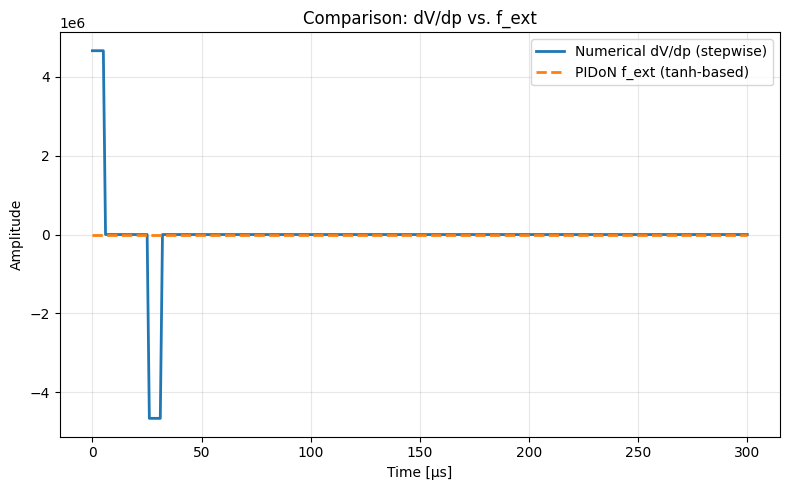

In [7]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# 1) 시간축 정의 (실시간 단위: µs)
# ----------------------------
T_ = torch.linspace(0, 3e-4, 300)  # 0~300 µs, 300 pts
dt = T_[1] - T_[0]

# ----------------------------
# 2) 수치해석 코드 방식 (dV/dp 직접 정의)
# ----------------------------
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 28  # pulse params

dVdp = (
    V_max/t1 * (1 - (T_ > t1).float())
    - V_max/(t3 - t2) * ((T_ > t2).float() - (T_ > t3).float())
)

# ----------------------------
# 3) PIDoN 방식 (tanh 기반 smooth H)
# ----------------------------
α_scale = 1e-2
Vmax_pidon = 40 * α_scale
t1_pidon, t2_pidon, t3_pidon = 6e-6, 26e-6, 32e-6  # 동일 단위 적용
σ = 0.0565

H = lambda τ: 0.5 * (1.0 + torch.tanh(σ * τ))

def f_ext(t, F_gain=1.0):
    return (F_gain * Vmax_pidon / t1_pidon) * (H(t) - H(t - t1_pidon)) + \
           (F_gain * Vmax_pidon / (t3_pidon - t2_pidon)) * (H(t - t2_pidon) - H(t - t3_pidon))

f_pidon = f_ext(T_, F_gain=1.0)

# ----------------------------
# 4) 시각화
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(T_*1e6, dVdp, label="Numerical dV/dp (stepwise)", lw=2)
plt.plot(T_*1e6, f_pidon, label="PIDoN f_ext (tanh-based)", lw=2, linestyle="--")
plt.xlabel("Time [µs]")
plt.ylabel("Amplitude")
plt.title("Comparison: dV/dp vs. f_ext")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

q_sol.shape = torch.Size([120, 3003])
qdot_sol.shape = torch.Size([120, 3003])


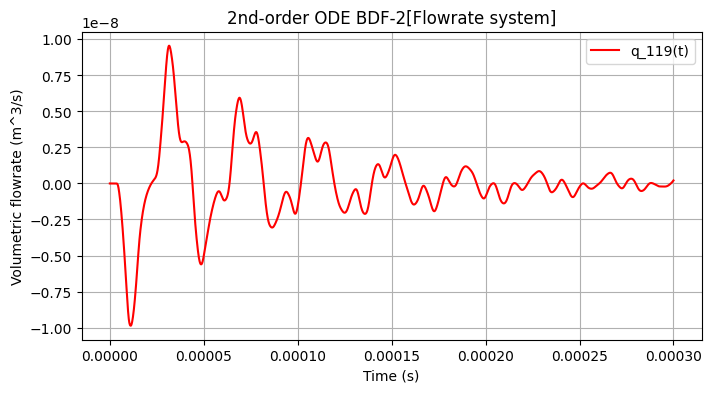

In [53]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------

partition1, partition2, partition3, partition4  = 30, 30, 30, 30
partition_tot = partition1 + partition2 + partition3 + partition4  # 120

sigma = 0.047
mu    = 0.0157
rho   = 1111.4
alpha = 0.29e-9
c     = 1600

r      = 235e-6
r_nozz = 25e-6
l1 = 0.012
l2 = 0.0084
l3 = 0.00542303
l4 = 0.00057697

# Characteristic time considering viscous effects
T_visc = 2*(l1 + l2 + l3 + l4)/c
delta_v = torch.sqrt(mu * T_visc / torch.tensor(math.pi) / rho)

# 1) Dividing radius and length by segment
ri = torch.tensor([r + (r_nozz - r)/partition4 * i for i in range(1, partition4+1)])
ri = torch.cat([r*torch.ones(partition_tot - partition4), ri])
li = torch.cat([
    l1/partition1*torch.ones(partition1),
    l2/partition2*torch.ones(partition2),
    l3/partition3*torch.ones(partition3),
    l4/partition4*torch.ones(partition4)
])

# 2) State-space elements (cap, ind, res)
cap = (torch.pi*(ri**2)*li/(c**2)/rho)
cap[-1] = (torch.pi*(r_nozz**4)/3/sigma)

ind = (rho*li/torch.pi/(ri**2))
res = (2*mu*li/torch.pi/delta_v/(ri**3))

# 3) Matrices needed for "second-order" differential equation
#    q''(t) = A * q(t) + B * q'(t) + f(t)
#    Here, A = L_mat * C_mat, B = R_mat
#
#    L_mat, C_mat, R_mat are constructed as follows
partition_N = partition_tot

# eye, zeros
I_N = torch.eye(partition_N)
Z_N = torch.zeros((partition_N, partition_N))

# L_mat
L_mat = torch.roll(I_N*(1.0/ind), -1, dims=1) - I_N*(1.0/ind)
L_mat[0, -1] = 0

# C_mat
C_mat = -torch.roll(I_N*(1.0/cap), 1, dims=1) + I_N*(1.0/cap)
C_mat[-1, 0] = 0

# R_mat
R_mat = -I_N*(res/ind)

A_mat = L_mat @ C_mat   # Term multiplied by q(t)
B_mat = R_mat           # Term multiplied by q'(t)


# 4) External force f(t) = f_2nd_bot
#    In the original code, f_2nd = [ 0; L_mat @ f_1st ]
#    ⇒ For our direct use, f_2nd_bot = L_mat @ f_1st
B_q_bot = torch.cat([
    torch.zeros(partition1,1),
    torch.ones(partition2,1),
    torch.zeros(partition3+partition4,1)
], dim=0)

T_ = torch.linspace(0, 3e-4, 3002)  # 0 to 1 second, 3001 steps + 1
dt = T_[1] - T_[0]
nT = len(T_)

t1, t2, t3, V_max = 6e-6, 26-6, 32e-6, 30
dVdp = (
    V_max/t1*(1 - (T_ > t1).float())
    - V_max/(t3 - t2)*((T_ > t2).float() - (T_ > t3).float())
)

f_1st = -(-B_q_bot*(c**2)*rho*2*alpha*dVdp.reshape(1,-1)/r) 
f_2nd_bot = L_mat @ f_1st  # (N, nT)

# 5) Initial conditions: q(0) & q'(0)
q_init   = torch.zeros(partition_N)
qdot_init= torch.zeros(partition_N)  # According to the problem setup, initial flow velocity = 0

# ----------------------------------------------------
# 6) (Important) Direct BDF-2 recursive function for a second-order differential system
# ----------------------------------------------------
def bdf2_solver_2nd_order(A, B, f_bot, q0, qdot0, dt):
    """
    Example function for directly solving the 2nd-order ODE
    q''(t) = A q(t) + B q'(t) + f(t)
    using BDF-2.

    Parameters
    ----------
    A : torch.Tensor, shape=(N,N)
    B : torch.Tensor, shape=(N,N)
    f_bot : torch.Tensor, shape=(N, nT)  # Forced term (vector) at each time
    q0 : torch.Tensor, shape=(N,)       # Initial q(0)
    qdot0 : torch.Tensor, shape=(N,)    # Initial q'(0)
    dt : float

    Returns
    -------
    q_hist : (N, nT+1)      # q(t_n) at each step
    qdot_hist : (N, nT+1)   # q'(t_n) at each step
    """
    N, nT = f_bot.shape
    # For storing results
    q_hist    = torch.zeros((N, nT+1), dtype=A.dtype, device=A.device)
    qdot_hist = torch.zeros((N, nT+1), dtype=A.dtype, device=A.device)

    # Record the initial conditions
    q_hist[:, 0]    = q0
    qdot_hist[:, 0] = qdot0

    # The first step (t=dt) requires x_{-1} for BDF-2
    # Usually, "2nd-order implicit integration" (or another 1-step method) is used to approximate q_1, qdot_1
    # Here, we simply try a "Backward Euler"-like approach for q_1:
    #   q''(t_0) ~ A q0 + B qdot0 + f(0)
    #   q'(t_0+dt) ~ qdot0 + dt*q''(t_0)
    #   q(t_0+dt)  ~ q0 + dt*q'(t_0+dt)
    f0       = f_bot[:, 0]  # shape=(N,)
    qddot0   = A @ q0 + B @ qdot0 + f0
    qdot_1   = qdot0 + dt * qddot0
    q_1      = q0 + dt * qdot_1

    q_hist[:, 1]    = q_1
    qdot_hist[:, 1] = qdot_1

    # Now, apply BDF-2 in earnest
    # BDF-2:
    #   (3 x_n - 4 x_{n-1} + x_{n-2}) / (2dt) = x'_n
    #   (3 x'_n - 4 x'_{n-1} + x'_{n-2}) / (2dt) = x''_n
    #
    # where x=q, x'=q', x''=q''= A q + B q' + f
    #
    # => We must formulate the equation for q_n (implicit).
    #    (Here, a straightforward direct approach is shown.)
    
    # Store previous steps
    q_nm2    = q0
    q_nm1    = q_1
    qdot_nm2 = qdot0
    qdot_nm1 = qdot_1

    # Time loop
    for i_step in range(2, nT+1):
        # External force at this step
        f_i = f_bot[:, i_step-1]  # shape=(N,)

        # Unknowns to solve for: q_n and qdot_n
        # 
        # (1) BDF-2 approximation: qdot_n = (3 q_n - 4 q_{n-1} + q_{n-2}) / (2dt)
        # (2) Another BDF-2 approximation: q''_n = (3 qdot_n - 4 qdot_{n-1} + qdot_{n-2}) / (2dt)
        #                                = A q_n + B qdot_n + f_i
        #
        # By combining the above, we can obtain a matrix form in q_n.
        #
        # (See the comments below for more detailed steps.)
        
        # 1) qdot_n = (3/2dt)*q_n + constant
        alpha   = 3.0/(2.0*dt)
        const_q = (-4.0/(2.0*dt))*q_nm1 + (1.0/(2.0*dt))*q_nm2

        # 2) q''_n = A q_n + B qdot_n + f_i
        #    Another BDF-2 form:
        #    q''_n = (3 qdot_n - 4 qdot_nm1 + qdot_nm2) / (2 dt)
        beta    = 3.0/(2.0*dt)
        const_d = (-4.0/(2.0*dt))*qdot_nm1 + (1.0/(2.0*dt))*qdot_nm2

        # Then:
        #   (3 qdot_n - 4 qdot_nm1 + qdot_nm2)/(2 dt) = A q_n + B qdot_n + f_i
        #
        #   beta*(alpha q_n + const_q) + const_d = A q_n + B*(alpha q_n + const_q) + f_i
        #   => (beta*alpha) q_n + beta*const_q + const_d = A q_n + B*alpha q_n + B*const_q + f_i
        #
        #   Collect terms in q_n:
        #   (beta*alpha - A - B*alpha) q_n = - (beta * const_q + const_d) + B*const_q - f_i
        #
        #   M_q = beta*alpha * I - A - alpha*B
        #   rhs = - (beta * const_q + const_d) + B@const_q - f_i
        #
        M_q  = beta*alpha * I_N - A - alpha*B
        rhs  = - (beta * const_q + const_d) + (B @ const_q) - f_i

        # Solve for q_n = M_q^-1 * rhs
        q_n = torch.linalg.solve(M_q, rhs)

        # qdot_n = alpha * q_n + const_q
        qdot_n = alpha * q_n + const_q

        # Save in storage
        q_hist[:, i_step]    = q_n
        qdot_hist[:, i_step] = qdot_n

        # Use the current step results as past values for the next loop
        q_nm2    = q_nm1
        q_nm1    = q_n
        qdot_nm2 = qdot_nm1
        qdot_nm1 = qdot_n

    return q_hist, qdot_hist


# -----------------------------------------------------
# 7) Solve the second-order ODE using BDF-2
# -----------------------------------------------------
q_sol, qdot_sol = bdf2_solver_2nd_order(
    A_mat, B_mat, f_2nd_bot,
    q_init, qdot_init, dt
)

print("q_sol.shape =", q_sol.shape)       # (N, nT+1), N=120, nT=3002
print("qdot_sol.shape =", qdot_sol.shape) # (N, nT+1)

# 8) Example: plot the flow at a specific index
i_q = 119
q_2nd_all = q_sol[i_q, :].detach().cpu().numpy()  # length = nT+1 = 3003
# Exclude the very first value (q(0)) and consider from t=dt
q_2nd = q_2nd_all[1:]   # (3002 elements)

T_plot = T_.numpy()     # 3002 time points, including the initial 0s
plt.figure(figsize=(8,4))
plt.plot(T_plot, q_2nd, 'r-', label=f"q_{i_q}(t)")
plt.title("2nd-order ODE BDF-2[Flowrate system]")
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flowrate (m^3/s)")
plt.grid(True)
plt.legend()
plt.show()


In [28]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------
partition1, partition2, partition3, partition4 = 30, 30, 30, 30
partition_tot = partition1 + partition2 + partition3 + partition4  # 120

sigma = 0.047        # N / m
mu    = 0.0157       # Pa·s
rho   = 1111.4       # kg / m³
alpha = 0.29e-9      # C / N
c     = 1600         # m / s

r      = 235e-6      # supply-channel radius
r_nozz = 25e-6       # nozzle radius
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697

# -----------------------------------------------------------------
# 1) Characteristic time and viscous penetration depth
# -----------------------------------------------------------------
T_visc  = 2 * (l1 + l2 + l3 + l4) / c
delta_v = torch.sqrt(mu * T_visc / torch.tensor(math.pi) / rho)     # tensor

l_tot = l1 + l2 + l3 + l4

C_channel = math.pi * (r ** 2) * l_tot / (c ** 2) / rho       # compliance
C_nozzle  = math.pi * (r_nozz ** 4) / (3 * sigma)              # nozzle compliance

print(f"C_channel = {C_channel:.6e}  [m³ / Pa]   (supply channel)")
print(f"C_nozzle  = {C_nozzle:.6e}  [m³ / Pa]   (nozzle compliance)")

# -----------------------------------------------------------------
# 2) Whole-channel (no partition) R, L, C, F
# -----------------------------------------------------------------
Vt=1
C_total   = C_channel + C_nozzle                               # 전체(compliance)
L_total = rho * l_tot / (math.pi * r ** 2)                     # inductance
R_total = 2 * mu * l_tot / (math.pi * delta_v.item() * r ** 3) # resistance
F = -(-(c**2) * rho * 2 * alpha * Vt / r)

print("\n===== Lumped parameters =====")
print(f"R_total  = {R_total:.6e}  [Pa·s / m³]")
print(f"L_total  = {L_total:.6e}  [kg / m⁴]")
print(f"C_total  = {C_total:.6e}  [m³ / Pa]   (channel + nozzle)")
print(f"F = {F:.6e}  [Pa]")

# -----------------------------------------------------------------
# 2-1) Dynamic response parameters
# -----------------------------------------------------------------
omega_0 = math.sqrt(1.0 / (L_total * C_total))  # natural angular frequency
alpha_d = R_total / (2.0 * L_total)             # damping coefficient
zeta    = alpha_d / omega_0                     # damping ratio

# ───────────────────────────────────────────────
# Definition of ω_d under different damping cases
#
# ζ < 1 (Underdamped):
#     ω_d = ω₀ * sqrt(1 − ζ²)
#
# ζ = 1 (Critically damped):
#     ω_d = 0   (no oscillation)
#
# ζ > 1 (Overdamped):
#     ω_d is not defined
#     Instead, two real roots s1 and s2 are used:
#         s1 = −α + ω₀ * sqrt(ζ² − 1)
#         s2 = −α − ω₀ * sqrt(ζ² − 1)
# ───────────────────────────────────────────────

if zeta < 1.0:
    omega_d = omega_0 * math.sqrt(1 - zeta**2)  # damped natural frequency
else:
    omega_d = 0.0

print("\n===== Dynamic Response Parameters =====")
print(f"α (damping coefficient) = {alpha_d:.6e}  [1/s]")
print(f"ω0 (natural angular freq) = {omega_0:.6e}  [rad/s]")
print(f"ζ (damping ratio) = {zeta:.6f}  [-]")
print(f"ωd (damped angular freq) = {omega_d:.6e}  [rad/s]")

# -----------------------------------------------------------------
# 3) External driving waveform → dVdp
# -----------------------------------------------------------------
T_ = torch.linspace(0, 3e-4, 300)  # 0 ~ 300 µs, 300 points
dt = T_[1] - T_[0]

# Pulse parameters (example)
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 28  # [s], [V]

# Voltage derivative profile (dV/dt type pulse shaping)
dVdp = (
    V_max/t1 * (1 - (T_ > t1).float())
    - V_max/(t3 - t2) * ((T_ > t2).float() - (T_ > t3).float())
)

print("\n===== Waveform-derived values =====")
print(f"dVdp vector shape = {dVdp.shape}  [V/s]")
print("dVdp (first 10 values):", dVdp[:10].numpy(), " [V/s]")

# -----------------------------------------------------------------
# 4) Estimation d²q/dt²,  dq/dt, q(t)
# -----------------------------------------------------------------
# L * d²q/dt² + R * dq/dt + (1/C) * q(t) = F * dV/dt
# Iteration refinement


C_channel = 1.609827e-18  [m³ / Pa]   (supply channel)
C_nozzle  = 8.703437e-18  [m³ / Pa]   (nozzle compliance)

===== Lumped parameters =====
R_total  = 1.669104e+12  [Pa·s / m³]
L_total  = 1.691176e+08  [kg / m⁴]
C_total  = 1.031326e-17  [m³ / Pa]   (channel + nozzle)
F = 7.022156e+03  [Pa]

===== Dynamic Response Parameters =====
α (damping coefficient) = 4.934745e+03  [1/s]
ω0 (natural angular freq) = 2.394460e+04  [rad/s]
ζ (damping ratio) = 0.206090  [-]
ωd (damped angular freq) = 2.343058e+04  [rad/s]

===== Waveform-derived values =====
dVdp vector shape = torch.Size([300])  [V/s]
dVdp (first 10 values): [4666666.5 4666666.5 4666666.5 4666666.5 4666666.5 4666666.5       0.
       0.        0.        0. ]  [V/s]



===== Iterative Residual Correction Results =====
     time[s] |            q |        dq/dt |      d²q/dt² |     residual
    0.00e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00 |   -3.277e+10
    1.00e-06 |    1.951e-10 |    1.944e-04 |    1.917e+02 |    0.000e+00
    2.01e-06 |    5.832e-10 |    3.868e-04 |    1.896e+02 |    0.000e+00
    3.01e-06 |    1.162e-09 |    5.771e-04 |    1.874e+02 |    0.000e+00
    4.01e-06 |    1.930e-09 |    7.651e-04 |    1.851e+02 |   -3.815e-06
    5.02e-06 |    2.884e-09 |    9.508e-04 |    1.827e+02 |    0.000e+00
    6.02e-06 |    4.022e-09 |    1.134e-03 |    1.803e+02 |    3.277e+10
    7.02e-06 |    5.146e-09 |    1.121e-03 |   -1.401e+01 |    1.192e-07
    8.03e-06 |    6.256e-09 |    1.107e-03 |   -1.451e+01 |    2.384e-07
    9.03e-06 |    7.352e-09 |    1.092e-03 |   -1.499e+01 |   -1.192e-07


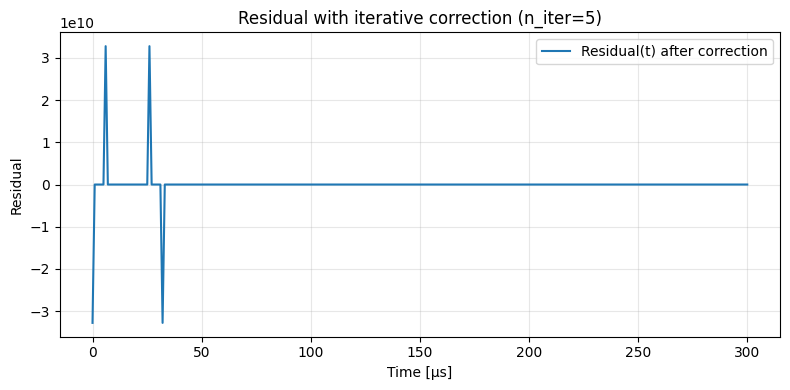

In [29]:
# -----------------------------------------------------------------
# 4) Estimate q(t), dq/dt, d²q/dt² with iterative residual correction
# -----------------------------------------------------------------
q  = torch.zeros_like(T_)
dq = torch.zeros_like(T_)
d2q= torch.zeros_like(T_)

n_iter = 5  # 각 스텝당 보정 반복 횟수

for i in range(1, len(T_)):
    dv = dVdp[i-1]  # 입력 (dV/dt)

    # 초기 예측 (Euler 1회)
    q_dd = (F*dv - R_total*dq[i-1] - (1.0/C_total)*q[i-1]) / L_total
    dq_new = dq[i-1] + q_dd*dt
    q_new  = q[i-1] + dq_new*dt

    # 반복 보정
    for k in range(n_iter):
        # 현재 상태에서 residual 계산
        res = L_total*q_dd + R_total*dq_new + (1.0/C_total)*q_new - F*dv

        # residual을 분배해서 보정 (간단화된 Newton step 개념)
        dq_new = dq_new - (res / (R_total + 1e-20))*dt
        q_new  = q_new  - (res / ((1.0/C_total) + 1e-20))*dt

        # 새 보정된 값으로 q_dd 업데이트
        q_dd = (F*dv - R_total*dq_new - (1.0/C_total)*q_new) / L_total

    # 최종 업데이트
    dq[i]  = dq_new
    q[i]   = q_new
    d2q[i] = q_dd

# Residual 계산 (최종 보정 결과)
residual = L_total*d2q + R_total*dq + (1.0/C_total)*q - F*dVdp

# 앞부분 출력
print("\n===== Iterative Residual Correction Results =====")
print(f"{'time[s]':>12} | {'q':>12} | {'dq/dt':>12} | {'d²q/dt²':>12} | {'residual':>12}")
for i in range(10):
    print(f"{T_[i]:12.2e} | {q[i]:12.3e} | {dq[i]:12.3e} | {d2q[i]:12.3e} | {residual[i]:12.3e}")

# Residual 시각화
plt.figure(figsize=(8,4))
plt.plot(T_*1e6, residual, label="Residual(t) after correction")
plt.xlabel("Time [µs]")
plt.ylabel("Residual")
plt.title(f"Residual with iterative correction (n_iter={n_iter})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────
# Average values of dynamic response
#
#   q        |     dq/dt    |    d²q/dt²   |   residual
# 1.930e-09  |   7.651e-04  |   1.851e+02  |  -3.815e-06
# ───────────────────────────────────────────────


In [15]:
# -----------------------------------------------------------------
# 5) Relative errors for q, dq/dt, d²q/dt²
# -----------------------------------------------------------------
eps = 1e-20  # division by zero 방지용

rel_err_q   = torch.abs(residual) / (torch.abs((1.0/C_total)*q)   + eps)
rel_err_dq  = torch.abs(residual) / (torch.abs(R_total*dq)        + eps)
rel_err_d2q = torch.abs(residual) / (torch.abs(L_total*d2q)       + eps)

print("\n===== Relative Errors =====")
print(f"{'time[s]':>12} | {'q':>12} | {'dq/dt':>12} | {'d²q/dt²':>12} | "
      f"{'residual':>12} | {'ε_q':>12} | {'ε_dq':>12} | {'ε_d2q':>12}")
for i in range(10):
    print(f"{T_[i]:12.2e} | {q[i]:12.3e} | {dq[i]:12.3e} | {d2q[i]:12.3e} | "
          f"{residual[i]:12.3e} | {rel_err_q[i]:12.3e} | "
          f"{rel_err_dq[i]:12.3e} | {rel_err_d2q[i]:12.3e}")



===== Relative Errors =====
     time[s] |            q |        dq/dt |      d²q/dt² |     residual |          ε_q |         ε_dq |        ε_d2q
    0.00e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00 |   -3.277e+10 |    3.277e+30 |    3.277e+30 |    3.277e+30
    1.00e-06 |    1.951e-10 |    1.944e-04 |    1.917e+02 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    2.01e-06 |    5.832e-10 |    3.868e-04 |    1.896e+02 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    3.01e-06 |    1.162e-09 |    5.771e-04 |    1.874e+02 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    4.01e-06 |    1.930e-09 |    7.651e-04 |    1.851e+02 |   -3.815e-06 |    2.039e-14 |    2.987e-15 |    1.219e-16
    5.02e-06 |    2.884e-09 |    9.508e-04 |    1.827e+02 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    6.02e-06 |    4.022e-09 |    1.134e-03 |    1.803e+02 |    3.277e+10 |    8.404e+01 |    1.731e+01 |    1.075e+00
    7.02e-06 |    5.146e-09

---

Normalize

q_sol.shape = torch.Size([120, 3003])
qdot_sol.shape = torch.Size([120, 3003])


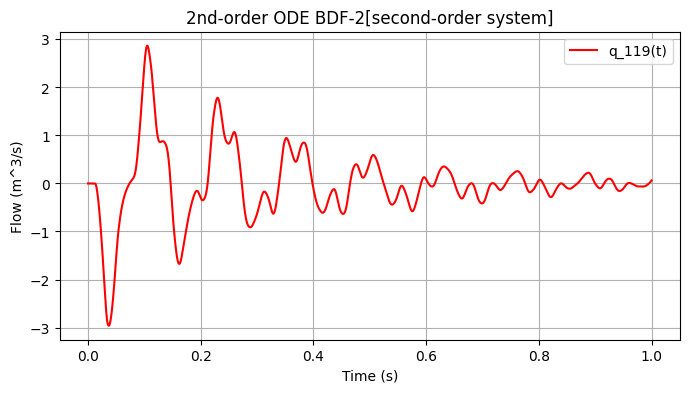

In [56]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------
Norm_U = (3e-4)
Norm_C = ((1e-12*3e-4))
Norm_L = ((3e-4)/1e-12) 
Norm_R = (1/1e-12)

partition1, partition2, partition3, partition4  = 30, 30, 30, 30
partition_tot = partition1 + partition2 + partition3 + partition4  # 120

sigma = 0.047
mu    = 0.0157
rho   = 1111.4
alpha = 0.29e-9
c     = 1600

r      = 235e-6
r_nozz = 25e-6
l1 = 0.012
l2 = 0.0084
l3 = 0.00542303
l4 = 0.00057697

# Characteristic time considering viscous effects
T_visc = 2*(l1 + l2 + l3 + l4)/c
delta_v = torch.sqrt(mu * T_visc / torch.tensor(math.pi) / rho)

# 1) Dividing radius and length by segment
ri = torch.tensor([r + (r_nozz - r)/partition4 * i for i in range(1, partition4+1)])
ri = torch.cat([r*torch.ones(partition_tot - partition4), ri])
li = torch.cat([
    l1/partition1*torch.ones(partition1),
    l2/partition2*torch.ones(partition2),
    l3/partition3*torch.ones(partition3),
    l4/partition4*torch.ones(partition4)
])

# 2) State-space elements (cap, ind, res)
cap = (torch.pi*(ri**2)*li/(c**2)/rho) / Norm_C
cap[-1] = (torch.pi*(r_nozz**4)/3/sigma)/ Norm_C

ind = (rho*li/torch.pi/(ri**2)) / Norm_L
res = (2*mu*li/torch.pi/delta_v/(ri**3)) / Norm_R

# 3) Matrices needed for "second-order" differential equation
#    q''(t) = A * q(t) + B * q'(t) + f(t)
#    Here, A = L_mat * C_mat, B = R_mat
#
#    L_mat, C_mat, R_mat are constructed as follows
partition_N = partition_tot

# eye, zeros
I_N = torch.eye(partition_N)
Z_N = torch.zeros((partition_N, partition_N))

# L_mat
L_mat = torch.roll(I_N*(1.0/ind), -1, dims=1) - I_N*(1.0/ind)
L_mat[0, -1] = 0

# C_mat
C_mat = -torch.roll(I_N*(1.0/cap), 1, dims=1) + I_N*(1.0/cap)
C_mat[-1, 0] = 0

# R_mat
R_mat = -I_N*(res/ind)

A_mat = L_mat @ C_mat   # Term multiplied by q(t)
B_mat = R_mat           # Term multiplied by q'(t)


# 4) External force f(t) = f_2nd_bot
#    In the original code, f_2nd = [ 0; L_mat @ f_1st ]
#    ⇒ For our direct use, f_2nd_bot = L_mat @ f_1st
B_q_bot = torch.cat([
    torch.zeros(partition1,1),
    torch.ones(partition2,1),
    torch.zeros(partition3+partition4,1)
], dim=0)

T_ = torch.linspace(0, 1, 3002)  # 0 to 1 second, 3001 steps + 1
dt = T_[1] - T_[0]
nT = len(T_)

t1, t2, t3, V_max = (6e-2)/3, (26-2)/3, (32e-2)/3, 30
dVdp = (
    V_max/t1*(1 - (T_ > t1).float())
    - V_max/(t3 - t2)*((T_ > t2).float() - (T_ > t3).float())
)

f_1st = -(-B_q_bot*(c**2)*rho*2*alpha*dVdp.reshape(1,-1)/r) * Norm_U

f_test = -(-(c**2)*rho*2*alpha*dVdp.reshape(1,-1)/r) * Norm_U


f_2nd_bot = L_mat @ f_1st  # (N, nT)

# 5) Initial conditions: q(0) & q'(0)
q_init   = torch.zeros(partition_N)
qdot_init= torch.zeros(partition_N)  # According to the problem setup, initial flow velocity = 0

# ----------------------------------------------------
# 6) (Important) Direct BDF-2 recursive function for a second-order differential system
# ----------------------------------------------------
def bdf2_solver_2nd_order(A, B, f_bot, q0, qdot0, dt):
    """
    Example function for directly solving the 2nd-order ODE
    q''(t) = A q(t) + B q'(t) + f(t)
    using BDF-2.

    Parameters
    ----------
    A : torch.Tensor, shape=(N,N)
    B : torch.Tensor, shape=(N,N)
    f_bot : torch.Tensor, shape=(N, nT)  # Forced term (vector) at each time
    q0 : torch.Tensor, shape=(N,)       # Initial q(0)
    qdot0 : torch.Tensor, shape=(N,)    # Initial q'(0)
    dt : float

    Returns
    -------
    q_hist : (N, nT+1)      # q(t_n) at each step
    qdot_hist : (N, nT+1)   # q'(t_n) at each step
    """
    N, nT = f_bot.shape
    # For storing results
    q_hist    = torch.zeros((N, nT+1), dtype=A.dtype, device=A.device)
    qdot_hist = torch.zeros((N, nT+1), dtype=A.dtype, device=A.device)

    # Record the initial conditions
    q_hist[:, 0]    = q0
    qdot_hist[:, 0] = qdot0

    # The first step (t=dt) requires x_{-1} for BDF-2
    # Usually, "2nd-order implicit integration" (or another 1-step method) is used to approximate q_1, qdot_1
    # Here, we simply try a "Backward Euler"-like approach for q_1:
    #   q''(t_0) ~ A q0 + B qdot0 + f(0)
    #   q'(t_0+dt) ~ qdot0 + dt*q''(t_0)
    #   q(t_0+dt)  ~ q0 + dt*q'(t_0+dt)
    f0       = f_bot[:, 0]  # shape=(N,)
    qddot0   = A @ q0 + B @ qdot0 + f0
    qdot_1   = qdot0 + dt * qddot0
    q_1      = q0 + dt * qdot_1

    q_hist[:, 1]    = q_1
    qdot_hist[:, 1] = qdot_1

    # Now, apply BDF-2 in earnest
    # BDF-2:
    #   (3 x_n - 4 x_{n-1} + x_{n-2}) / (2dt) = x'_n
    #   (3 x'_n - 4 x'_{n-1} + x'_{n-2}) / (2dt) = x''_n
    #
    # where x=q, x'=q', x''=q''= A q + B q' + f
    #
    # => We must formulate the equation for q_n (implicit).
    #    (Here, a straightforward direct approach is shown.)
    
    # Store previous steps
    q_nm2    = q0
    q_nm1    = q_1
    qdot_nm2 = qdot0
    qdot_nm1 = qdot_1

    # Time loop
    for i_step in range(2, nT+1):
        # External force at this step
        f_i = f_bot[:, i_step-1]  # shape=(N,)

        # Unknowns to solve for: q_n and qdot_n
        # 
        # (1) BDF-2 approximation: qdot_n = (3 q_n - 4 q_{n-1} + q_{n-2}) / (2dt)
        # (2) Another BDF-2 approximation: q''_n = (3 qdot_n - 4 qdot_{n-1} + qdot_{n-2}) / (2dt)
        #                                = A q_n + B qdot_n + f_i
        #
        # By combining the above, we can obtain a matrix form in q_n.
        #
        # (See the comments below for more detailed steps.)
        
        # 1) qdot_n = (3/2dt)*q_n + constant
        alpha   = 3.0/(2.0*dt)
        const_q = (-4.0/(2.0*dt))*q_nm1 + (1.0/(2.0*dt))*q_nm2

        # 2) q''_n = A q_n + B qdot_n + f_i
        #    Another BDF-2 form:
        #    q''_n = (3 qdot_n - 4 qdot_nm1 + qdot_nm2) / (2 dt)
        beta    = 3.0/(2.0*dt)
        const_d = (-4.0/(2.0*dt))*qdot_nm1 + (1.0/(2.0*dt))*qdot_nm2

        # Then:
        #   (3 qdot_n - 4 qdot_nm1 + qdot_nm2)/(2 dt) = A q_n + B qdot_n + f_i
        #
        #   beta*(alpha q_n + const_q) + const_d = A q_n + B*(alpha q_n + const_q) + f_i
        #   => (beta*alpha) q_n + beta*const_q + const_d = A q_n + B*alpha q_n + B*const_q + f_i
        #
        #   Collect terms in q_n:
        #   (beta*alpha - A - B*alpha) q_n = - (beta * const_q + const_d) + B*const_q - f_i
        #
        #   M_q = beta*alpha * I - A - alpha*B
        #   rhs = - (beta * const_q + const_d) + B@const_q - f_i
        #
        M_q  = beta*alpha * I_N - A - alpha*B
        rhs  = - (beta * const_q + const_d) + (B @ const_q) - f_i

        # Solve for q_n = M_q^-1 * rhs
        q_n = torch.linalg.solve(M_q, rhs)

        # qdot_n = alpha * q_n + const_q
        qdot_n = alpha * q_n + const_q

        # Save in storage
        q_hist[:, i_step]    = q_n
        qdot_hist[:, i_step] = qdot_n

        # Use the current step results as past values for the next loop
        q_nm2    = q_nm1
        q_nm1    = q_n
        qdot_nm2 = qdot_nm1
        qdot_nm1 = qdot_n

    return q_hist, qdot_hist


# -----------------------------------------------------
# 7) Solve the second-order ODE using BDF-2
# -----------------------------------------------------
q_sol, qdot_sol = bdf2_solver_2nd_order(
    A_mat, B_mat, f_2nd_bot,
    q_init, qdot_init, dt
)

print("q_sol.shape =", q_sol.shape)       # (N, nT+1), N=120, nT=3002
print("qdot_sol.shape =", qdot_sol.shape) # (N, nT+1)

# 8) Example: plot the flow at a specific index
i_q = 119
q_2nd_all = q_sol[i_q, :].detach().cpu().numpy()  # length = nT+1 = 3003
# Exclude the very first value (q(0)) and consider from t=dt
q_2nd = q_2nd_all[1:]   # (3002 elements)

T_plot = T_.numpy()     # 3002 time points, including the initial 0s
plt.figure(figsize=(8,4))
plt.plot(T_plot, q_2nd, 'r-', label=f"q_{i_q}(t)")
plt.title("2nd-order ODE BDF-2[second-order system]")
plt.xlabel("Time (s)")
plt.ylabel("Flow (m^3/s)")
plt.grid(True)
plt.legend()
plt.show()



T_[0], T_[-1], len(T_), dt = 0.0 1.0 3002 0.0003332222592469177
q_sol shape: (120, 3002)  qdot_sol shape: (120, 3002)
[Amplitudes]  |q|≈4.21, |q'|≈235, |q''|≈4.54e+04
[Omega est]   q'/q ≈ 55.8 s^-1,   q''/q' ≈ 193 s^-1


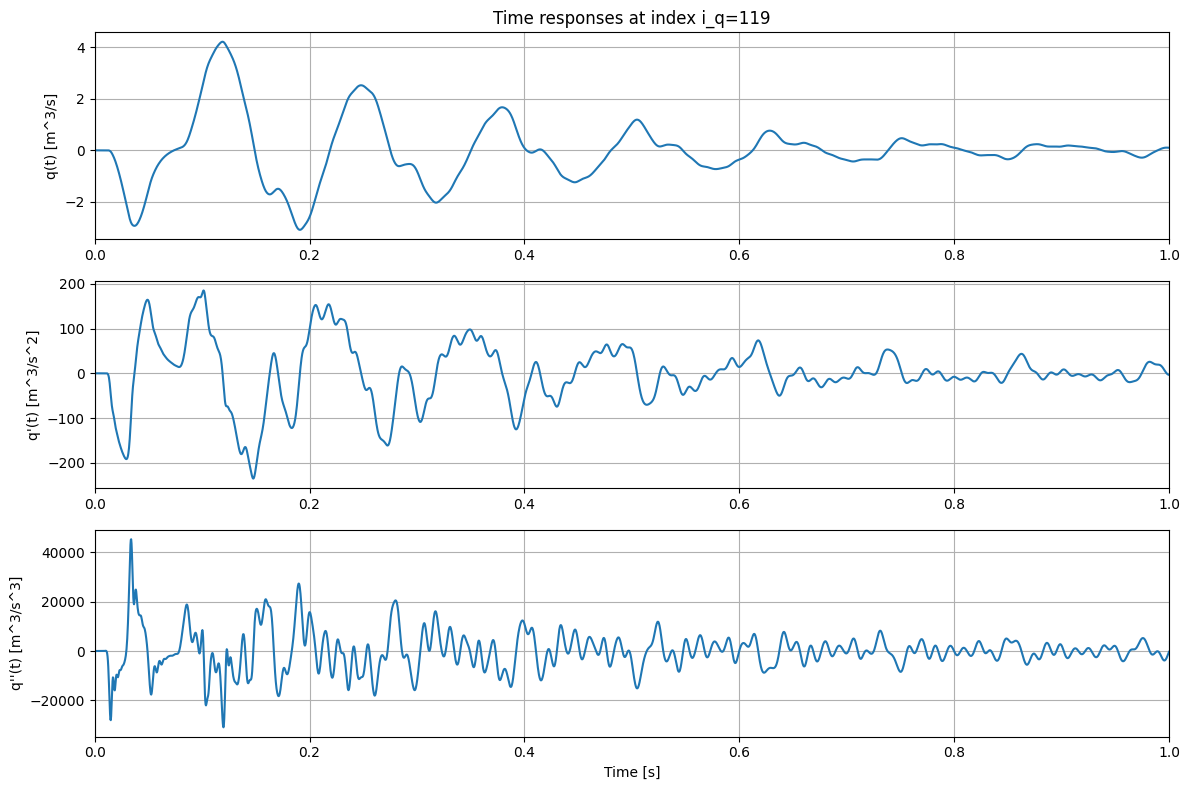

In [57]:
# ===============================
# 재설정: 시간축/외력/적분/시각화
# ===============================
import numpy as np
import torch, matplotlib.pyplot as plt

# 1) 시간 그리드 고정
T_END   = 1.0
N_STEPS = 3002
T_      = torch.linspace(0.0, T_END, N_STEPS)
dt      = T_[1] - T_[0]
print("T_[0], T_[-1], len(T_), dt =", float(T_[0]), float(T_[-1]), len(T_), float(dt))

# 2) 사다리꼴 전압 미분 dV/dp (오타 수정: 26-2/3 -> 26e-2/3)
t1 = 6e-2/3      # 0.02 s
t2 = 26e-2/3     # 0.086666... s
t3 = 32e-2/3     # 0.106666... s
V_max = 30.0
assert 0 < t1 < t2 < t3 < T_END, f"Check t1,t2,t3: {(t1, t2, t3)} must be inside (0, {T_END})"

H = lambda x: (x > 0).to(T_)
dVdp = ( V_max/t1 * (1 - H(T_ - t1))
       - V_max/(t3 - t2) * (H(T_ - t2) - H(T_ - t3)) )

# 3) 외력 f(t): 전체 시간축용 f_full, 적분 입력용 f_bot(= t=dt..T_END)
f_1st   = -(-B_q_bot*(c**2)*rho*2*alpha*dVdp.reshape(1, -1)/r) * Norm_U  # (N, N_STEPS)
f_full  = L_mat @ f_1st                                                   # (N, N_STEPS)
f_bot   = f_full[:, 1:]                                                   # (N, N_STEPS-1)  <-- t=0 제외

# 4) BDF-2 적분 (초기조건 0)
q_init    = torch.zeros(partition_tot)
qdot_init = torch.zeros(partition_tot)
q_sol, qdot_sol = bdf2_solver_2nd_order(A_mat, B_mat, f_bot, q_init, qdot_init, dt)

# 이제 q_sol, qdot_sol은 t=0..T_END에 정렬 → 열 개수 == N_STEPS
print("q_sol shape:", tuple(q_sol.shape), " qdot_sol shape:", tuple(qdot_sol.shape))
assert q_sol.shape[1] == N_STEPS, "Time alignment failed (columns must equal len(T_))"

# 5) q''(t) = A q + B q' + f (전체 시간축과 정렬)
qddot_full = A_mat @ q_sol + B_mat @ qdot_sol + f_full   # (N, N_STEPS)

# 6) 관심 인덱스에서 추출 및 스케일 검증
i_q = 119
assert 0 <= i_q < q_sol.shape[0], f"i_q={i_q} out of range"
q_t     = q_sol[i_q, :].detach().cpu().numpy()
qdot_t  = qdot_sol[i_q, :].detach().cpu().numpy()
qddot_t = qddot_full[i_q, :].detach().cpu().numpy()
T_plot  = T_.detach().cpu().numpy()

# 길이 검증
assert T_plot.shape[0] == q_t.shape[0] == qdot_t.shape[0] == qddot_t.shape[0]

# 스케일 수치 확인 (|q|, |q'|, |q''| 및 비율로 omega 추정)
eps = 1e-12
q_amp     = float(np.max(np.abs(q_t)))
qdot_amp  = float(np.max(np.abs(qdot_t)))
qddot_amp = float(np.max(np.abs(qddot_t)))
omega1_est = qdot_amp / max(q_amp, eps)     # ~ 지배 각주파수 추정 1  (s^-1)
omega2_est = qddot_amp / max(qdot_amp, eps) # ~ 지배 각주파수 추정 2  (s^-1)
print(f"[Amplitudes]  |q|≈{q_amp:.3g}, |q'|≈{qdot_amp:.3g}, |q''|≈{qddot_amp:.3g}")
print(f"[Omega est]   q'/q ≈ {omega1_est:.3g} s^-1,   q''/q' ≈ {omega2_est:.3g} s^-1")

# 7) 시각화 (x축 0..1 s 고정)
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(T_plot, q_t)
plt.title(f"Time responses at index i_q={i_q}")
plt.ylabel("q(t) [m^3/s]")
plt.grid(True)
plt.xlim(0.0, T_END)

plt.subplot(3, 1, 2)
plt.plot(T_plot, qdot_t)
plt.ylabel("q'(t) [m^3/s^2]")
plt.grid(True)
plt.xlim(0.0, T_END)

plt.subplot(3, 1, 3)
plt.plot(T_plot, qddot_t)
plt.xlabel("Time [s]")
plt.ylabel("q''(t) [m^3/s^3]")
plt.grid(True)
plt.xlim(0.0, T_END)

plt.tight_layout()
plt.show()


In [42]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# --------------------------------
# 0) Basic constants and settings
# --------------------------------
torch.set_default_dtype(torch.float64)

# ----------------------------
# Normalization factors
# ----------------------------
Norm_F = (3e-4)
Norm_C = ((1e-12*3e-4))
Norm_L = ((3e-4)/1e-12) 
Norm_R = (1/1e-12)

partition1, partition2, partition3, partition4 = 30, 30, 30, 30
partition_tot = partition1 + partition2 + partition3 + partition4  # 120

sigma = 0.047        # N / m
mu    = 0.0157       # Pa·s
rho   = 1111.4       # kg / m³
alpha = 0.29e-9      # C / N
c     = 1600         # m / s

r      = 235e-6      # supply-channel radius
r_nozz = 25e-6       # nozzle radius
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697

# -----------------------------------------------------------------
# 1) Characteristic time and viscous penetration depth
# -----------------------------------------------------------------
T_visc  = 2 * (l1 + l2 + l3 + l4) / c
delta_v = torch.sqrt(mu * T_visc / torch.tensor(math.pi) / rho)     # tensor

l_tot = l1 + l2 + l3 + l4

C_channel = (math.pi * (r ** 2) * l_tot / (c ** 2) / rho) / Norm_C  # compliance
C_nozzle  = (math.pi * (r_nozz ** 4) / (3 * sigma)) / Norm_C             # nozzle compliance

print(f"C_channel = {C_channel:.6e}  [m³ / Pa]   (supply channel)")
print(f"C_nozzle  = {C_nozzle:.6e}  [m³ / Pa]   (nozzle compliance)")

# -----------------------------------------------------------------
# 2) Whole-channel (no partition) R, L, C, F
# -----------------------------------------------------------------
Vt=1
C_total   = C_channel + C_nozzle                               # 전체(compliance)
L_total = (rho * l_tot / (math.pi * r ** 2))/Norm_L                    # inductance
R_total = (2 * mu * l_tot / (math.pi * delta_v.item() * r ** 3))/Norm_R # resistance
F = -(-(c**2) * rho * 2 * alpha * Vt / r)*Norm_F

print("\n===== Lumped parameters =====")
print(f"R_total  = {R_total:.6e}  [Pa·s / m³]")
print(f"L_total  = {L_total:.6e}  [kg / m⁴]")
print(f"C_total  = {C_total:.6e}  [m³ / Pa]   (channel + nozzle)")
print(f"F = {F:.6e}  [Pa]")

# -----------------------------------------------------------------
# 2-1) Dynamic response parameters
# -----------------------------------------------------------------
omega_0 = math.sqrt(1.0 / (L_total * C_total))  # natural angular frequency
alpha_d = R_total / (2.0 * L_total)             # damping coefficient
zeta    = alpha_d / omega_0                     # damping ratio

# ───────────────────────────────────────────────
# Definition of ω_d under different damping cases
#
# ζ < 1 (Underdamped):
#     ω_d = ω₀ * sqrt(1 − ζ²)
#
# ζ = 1 (Critically damped):
#     ω_d = 0   (no oscillation)
#
# ζ > 1 (Overdamped):
#     ω_d is not defined
#     Instead, two real roots s1 and s2 are used:
#         s1 = −α + ω₀ * sqrt(ζ² − 1)
#         s2 = −α − ω₀ * sqrt(ζ² − 1)
# ───────────────────────────────────────────────

if zeta < 1.0:
    omega_d = omega_0 * math.sqrt(1 - zeta**2)  # damped natural frequency
else:
    omega_d = 0.0

print("\n===== Dynamic Response Parameters =====")
print(f"α (damping coefficient) = {alpha_d:.6e}  [1/s]")
print(f"ω0 (natural angular freq) = {omega_0:.6e}  [rad/s]")
print(f"ζ (damping ratio) = {zeta:.6f}  [-]")
print(f"ωd (damped angular freq) = {omega_d:.6e}  [rad/s]")

# -----------------------------------------------------------------
# 3) External driving waveform → dVdp
# -----------------------------------------------------------------
T_ = torch.linspace(0, 1, 300)  # 0 ~ 300 µs, 300 points
dt = T_[1] - T_[0]

# Pulse parameters (example)
t1, t2, t3, V_max = 6e-2/3, 26e-2/3, 32e-2/3, 28  # [s], [V]

# Voltage derivative profile (dV/dt type pulse shaping)
dVdp = (
    V_max/t1 * (1 - (T_ > t1).float())
    - V_max/(t3 - t2) * ((T_ > t2).float() - (T_ > t3).float())
)

print("\n===== Waveform-derived values =====")
print(f"dVdp vector shape = {dVdp.shape}  [V/s]")
print("dVdp (first 10 values):", dVdp[:10].numpy(), " [V/s]")

# -----------------------------------------------------------------
# 4) Estimation d²q/dt²,  dq/dt, q(t)
# -----------------------------------------------------------------
# L * d²q/dt² + R * dq/dt + (1/C) * q(t) = F * dV/dt
# Iteration refinement


C_channel = 5.366089e-03  [m³ / Pa]   (supply channel)
C_nozzle  = 2.901146e-02  [m³ / Pa]   (nozzle compliance)

===== Lumped parameters =====
R_total  = 1.669104e+00  [Pa·s / m³]
L_total  = 5.637252e-01  [kg / m⁴]
C_total  = 3.437755e-02  [m³ / Pa]   (channel + nozzle)
F = 2.106647e+00  [Pa]

===== Dynamic Response Parameters =====
α (damping coefficient) = 1.480424e+00  [1/s]
ω0 (natural angular freq) = 7.183380e+00  [rad/s]
ζ (damping ratio) = 0.206090  [-]
ωd (damped angular freq) = 7.029174e+00  [rad/s]

===== Waveform-derived values =====
dVdp vector shape = torch.Size([300])  [V/s]
dVdp (first 10 values): [1400. 1400. 1400. 1400. 1400. 1400.    0.    0.    0.    0.]  [V/s]



===== Iterative Residual Correction Results =====
     time[s] |            q |        dq/dt |      d²q/dt² |     residual
    0.00e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00 |   -2.949e+03
    3.34e-03 |    5.497e-02 |    1.744e+01 |    5.177e+03 |    0.000e+00
    6.69e-03 |    1.675e-01 |    3.469e+01 |    5.120e+03 |    4.547e-13
    1.00e-02 |    3.369e-01 |    5.174e+01 |    5.061e+03 |    0.000e+00
    1.34e-02 |    5.626e-01 |    6.860e+01 |    5.000e+03 |    0.000e+00
    1.67e-02 |    8.438e-01 |    8.525e+01 |    4.936e+03 |    0.000e+00
    2.01e-02 |    1.180e+00 |    1.017e+02 |    4.870e+03 |    2.949e+03
    2.34e-02 |    1.515e+00 |    1.005e+02 |   -3.756e+02 |    1.421e-14
    2.68e-02 |    1.846e+00 |    9.919e+01 |   -3.889e+02 |    7.105e-15
    3.01e-02 |    2.172e+00 |    9.787e+01 |   -4.019e+02 |    0.000e+00


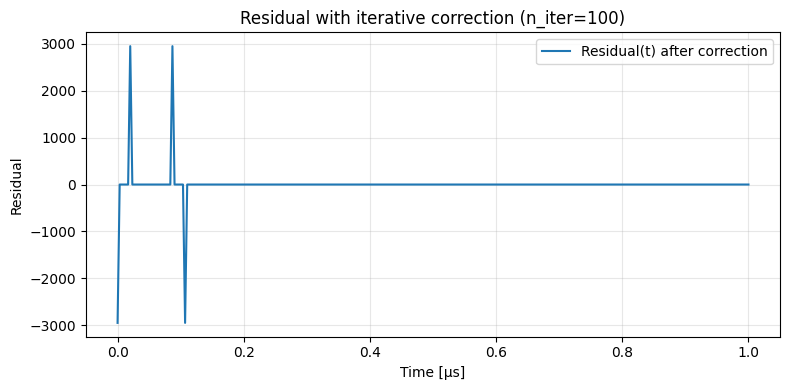

In [43]:
# -----------------------------------------------------------------
# 4) Estimate q(t), dq/dt, d²q/dt² with iterative residual correction
# -----------------------------------------------------------------
q  = torch.zeros_like(T_)
dq = torch.zeros_like(T_)
d2q= torch.zeros_like(T_)

n_iter = 100  # 각 스텝당 보정 반복 횟수

for i in range(1, len(T_)):
    dv = dVdp[i-1]  # 입력 (dV/dt)

    # 초기 예측 (Euler 1회)
    q_dd = (F*dv - R_total*dq[i-1] - (1.0/C_total)*q[i-1]) / L_total
    dq_new = dq[i-1] + q_dd*dt
    q_new  = q[i-1] + dq_new*dt

    # 반복 보정
    for k in range(n_iter):
        # 현재 상태에서 residual 계산
        res = L_total*q_dd + R_total*dq_new + (1.0/C_total)*q_new - F*dv

        # residual을 분배해서 보정 (간단화된 Newton step 개념)
        dq_new = dq_new - (res / (R_total + 1e-20))*dt
        q_new  = q_new  - (res / ((1.0/C_total) + 1e-20))*dt

        # 새 보정된 값으로 q_dd 업데이트
        q_dd = (F*dv - R_total*dq_new - (1.0/C_total)*q_new) / L_total

    # 최종 업데이트
    dq[i]  = dq_new
    q[i]   = q_new
    d2q[i] = q_dd

# Residual 계산 (최종 보정 결과)
residual = L_total*d2q + R_total*dq + (1.0/C_total)*q - F*dVdp

# 앞부분 출력
print("\n===== Iterative Residual Correction Results =====")
print(f"{'time[s]':>12} | {'q':>12} | {'dq/dt':>12} | {'d²q/dt²':>12} | {'residual':>12}")
for i in range(10):
    print(f"{T_[i]:12.2e} | {q[i]:12.3e} | {dq[i]:12.3e} | {d2q[i]:12.3e} | {residual[i]:12.3e}")

# Residual 시각화
plt.figure(figsize=(8,4))
plt.plot(T_, residual, label="Residual(t) after correction")
plt.xlabel("Time [µs]")
plt.ylabel("Residual")
plt.title(f"Residual with iterative correction (n_iter={n_iter})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────
# Average values of dynamic response
#
#   q        |     dq/dt    |    d²q/dt²   |   residual
#  1.694e+03 |    1.706e+05 |   -5.925e+05 |    2.183e-11
#  1.694e+00 |    1.706e+05 |   -5.925e+13 |    가정
# ───────────────────────────────────────────────


In [44]:
# -----------------------------------------------------------------
# 5) Relative errors for q, dq/dt, d²q/dt²
# -----------------------------------------------------------------
eps = 1e-20  # division by zero 방지용

rel_err_q   = torch.abs(residual) / (torch.abs((1.0/C_total)*q)   + eps)
rel_err_dq  = torch.abs(residual) / (torch.abs(R_total*dq)        + eps)
rel_err_d2q = torch.abs(residual) / (torch.abs(L_total*d2q)       + eps)

print("\n===== Relative Errors =====")
print(f"{'time[s]':>12} | {'q':>12} | {'dq/dt':>12} | {'d²q/dt²':>12} | "
      f"{'residual':>12} | {'ε_q':>12} | {'ε_dq':>12} | {'ε_d2q':>12}")
for i in range(10):
    print(f"{T_[i]:12.2e} | {q[i]:12.3e} | {dq[i]:12.3e} | {d2q[i]:12.3e} | "
          f"{residual[i]:12.3e} | {rel_err_q[i]:12.3e} | "
          f"{rel_err_dq[i]:12.3e} | {rel_err_d2q[i]:12.3e}")



===== Relative Errors =====
     time[s] |            q |        dq/dt |      d²q/dt² |     residual |          ε_q |         ε_dq |        ε_d2q
    0.00e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00 |   -2.949e+03 |    2.949e+23 |    2.949e+23 |    2.949e+23
    3.34e-03 |    5.497e-02 |    1.744e+01 |    5.177e+03 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    6.69e-03 |    1.675e-01 |    3.469e+01 |    5.120e+03 |    4.547e-13 |    9.334e-14 |    7.855e-15 |    1.575e-16
    1.00e-02 |    3.369e-01 |    5.174e+01 |    5.061e+03 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    1.34e-02 |    5.626e-01 |    6.860e+01 |    5.000e+03 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    1.67e-02 |    8.438e-01 |    8.525e+01 |    4.936e+03 |    0.000e+00 |    0.000e+00 |    0.000e+00 |    0.000e+00
    2.01e-02 |    1.180e+00 |    1.017e+02 |    4.870e+03 |    2.949e+03 |    8.594e+01 |    1.738e+01 |    1.074e+00
    2.34e-02 |    1.515e+00